In [1]:
import os
import numpy as np
import polars as pl
import datetime as dt
from dotenv import load_dotenv
from collections import defaultdict
import warnings
import time

warnings.filterwarnings('ignore')

# ── Configuration ──────────────────────────────────────────
WINDOW        = 252
INDUSTRY_COL  = 'naics'
RETURN_COL    = 'specific_return'
DATE_COL      = 'date'
ID_COL        = 'cusip'
MIN_PEERS     = 2     # minimum peers needed (3 stocks total = target + 2 peers)

RESULTS_DIR   = '/home/bpinoli/sub-industry-correlation/src/signal/full_results_naics'
NAICS_NAMES_PATH = '/home/bpinoli/sub-industry-correlation/data/2022_NAICS_Structure.xlsx'


# ── Load NAICS code -> name lookup ─────────────────────────

def load_naics_names() -> dict[str, str]:
    """Load 6-digit NAICS codes and their English titles from Census xlsx."""
    import openpyxl

    wb = openpyxl.load_workbook(NAICS_NAMES_PATH, read_only=True)
    ws = wb.active

    naics_names = {}
    for row in ws.iter_rows(min_row=1, values_only=True):
        code = row[1]
        title = row[2]
        if code is None or title is None:
            continue
        code_str = str(code).strip()
        title_str = str(title).strip().rstrip('T').rstrip('*').strip()
        if len(code_str) == 6 and code_str.isdigit():
            naics_names[code_str] = title_str

    wb.close()
    print(f"  Loaded {len(naics_names)} NAICS 6-digit industry names")
    return naics_names


def get_naics_label(code, naics_names: dict[str, str], max_len: int = 40) -> str:
    """Return 'CODE - Name' label, truncated if needed."""
    code_str = str(code)
    name = naics_names.get(code_str, "Unknown")
    if len(name) > max_len:
        name = name[:max_len - 1] + "…"
    return f"{code_str} - {name}"


# ── Core function: PCA eigenvalue extraction (top 1) ──────

def _extract_eigenvalues(
    target_cusip: str,
    peer_cusips: list[str],
    returns_wide: pl.DataFrame,
    dates: np.ndarray,
    window: int = WINDOW,
) -> pl.DataFrame:
    peer_arr = returns_wide.select(peer_cusips).to_numpy().astype(np.float64)

    eig_date, eig_val, eig_var_explained, eig_n_peers = [], [], [], []

    for t in range(window, len(dates)):
        start = t - window
        end   = t

        X_block = peer_arr[start:end]

        valid_mask = ~np.isnan(X_block).any(axis=0)
        X_valid = X_block[:, valid_mask]
        n_peers = X_valid.shape[1]

        if n_peers < MIN_PEERS:
            continue

        X_mean = X_valid.mean(axis=0)
        X_std = X_valid.std(axis=0)
        X_std[X_std == 0] = 1.0
        X_scaled = (X_valid - X_mean) / X_std

        S = np.linalg.svd(X_scaled, compute_uv=False)

        total_var = (S ** 2).sum()
        top_eigenvalue = S[0] ** 2 / (window - 1)
        top_var_explained = S[0] ** 2 / total_var if total_var > 0 else 0.0

        eig_date.append(dates[t].item())
        eig_val.append(top_eigenvalue)
        eig_var_explained.append(top_var_explained)
        eig_n_peers.append(n_peers)

    return pl.DataFrame({
        'date':            eig_date,
        'cusip':           [target_cusip] * len(eig_date),
        'top_eigenvalue':  eig_val,
        'var_explained':   eig_var_explained,
        'n_peers':         eig_n_peers,
    })


# ── Data loading ───────────────────────────────────────────

def load_data() -> pl.DataFrame:
    import sf_quant.data as sfd

    start = dt.date(2000, 1, 1)
    end = dt.date(2025, 1, 1)

    columns = [
        'ticker', 'date', 'barrid', 'cusip',
        'price', 'return', 'specific_return', 'specific_risk'
    ]

    df = sfd.load_assets(
        start=start,
        end=end,
        columns=columns,
        in_universe=True,
    ).filter(
        pl.col('price').shift(1).over('barrid').gt(5)
    )

    return df


def merge_industry_data(df: pl.DataFrame) -> pl.DataFrame:
    naics_df = pl.read_csv('/home/bpinoli/sub-industry-correlation/data/NAICS_00-26.csv')
    naics_df = naics_df.with_columns(
        pl.col('datadate').str.to_date('%Y-%m-%d')
    )

    naics_df = naics_df.select(['cusip', 'datadate', 'naics'])

    merged_df = df.join_asof(
        other=naics_df,
        left_on='date',
        right_on='datadate',
        by='cusip',
        strategy='backward',
    )

    return merged_df


# ── Graphs and tables ─────────────────────────────────────

def save_eigenvalue_analysis(all_eigenvalues_df: pl.DataFrame, naics_names: dict, results_dir: str):
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt

    print("\nGenerating eigenvalue analysis...")

    # ── 1. Overall summary table ──────────────────────────────
    summary = all_eigenvalues_df.select([
        pl.col('top_eigenvalue').mean().alias('mean'),
        pl.col('top_eigenvalue').median().alias('median'),
        pl.col('top_eigenvalue').std().alias('std'),
        pl.col('top_eigenvalue').min().alias('min'),
        pl.col('top_eigenvalue').max().alias('max'),
        pl.col('top_eigenvalue').quantile(0.25).alias('p25'),
        pl.col('top_eigenvalue').quantile(0.75).alias('p75'),
        pl.col('var_explained').mean().alias('mean_var_explained'),
        pl.col('var_explained').median().alias('median_var_explained'),
        pl.col('var_explained').std().alias('std_var_explained'),
        pl.col('var_explained').min().alias('min_var_explained'),
        pl.col('var_explained').max().alias('max_var_explained'),
        pl.col('n_peers').mean().alias('mean_peers'),
        pl.len().alias('n_observations'),
    ])

    summary_path = os.path.join(results_dir, 'eigenvalue_summary.csv')
    summary.write_csv(summary_path)
    print(f"  Saved eigenvalue summary to {summary_path}")
    print(summary)

    # ── 2. Per-NAICS summary ─────────────────────────────────
    per_naics = (
        all_eigenvalues_df
        .group_by('naics')
        .agg([
            pl.col('top_eigenvalue').mean().alias('mean_eigenvalue'),
            pl.col('top_eigenvalue').median().alias('median_eigenvalue'),
            pl.col('var_explained').mean().alias('mean_var_explained'),
            pl.col('var_explained').median().alias('median_var_explained'),
            pl.col('n_peers').mean().alias('mean_peers'),
            pl.len().alias('n_obs'),
        ])
        .sort('mean_var_explained', descending=True)
    )

    # Add English names
    per_naics = per_naics.with_columns(
        pl.col('naics').map_elements(
            lambda x: naics_names.get(str(x), "Unknown"), return_dtype=pl.Utf8
        ).alias('naics_name')
    )

    per_naics_path = os.path.join(results_dir, 'eigenvalue_by_naics.csv')
    per_naics.write_csv(per_naics_path)
    print(f"  Saved per-NAICS eigenvalue table to {per_naics_path}")
    print("\n  Top 15 NAICS codes by mean variance explained (top 1 PC):")
    print(per_naics.select(['naics', 'naics_name', 'mean_var_explained',
                            'mean_peers', 'n_obs']).head(15))

    # ── 3. Time series: daily average top eigenvalue ──────────
    daily_avg = (
        all_eigenvalues_df
        .group_by('date')
        .agg([
            pl.col('top_eigenvalue').mean().alias('avg_eigenvalue'),
            pl.col('var_explained').mean().alias('avg_var_explained'),
        ])
        .sort('date')
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    dates_plot = daily_avg['date'].to_list()
    axes[0].plot(dates_plot, daily_avg['avg_eigenvalue'].to_numpy(),
                 linewidth=0.5, alpha=0.8, color='steelblue')
    axes[0].set_ylabel('Avg Top Eigenvalue')
    axes[0].set_title('Daily Average Top PCA Eigenvalue — NAICS Peer Groups')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(dates_plot, daily_avg['avg_var_explained'].to_numpy(),
                 linewidth=0.5, alpha=0.8, color='darkorange')
    axes[1].set_ylabel('Avg Variance Explained')
    axes[1].set_xlabel('Date')
    axes[1].set_title('Daily Average Variance Explained by Top PC — NAICS Peer Groups')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(results_dir, 'eigenvalue_timeseries.png')
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"  Saved eigenvalue time series plot to {path}")

    # ── 4. Per-NAICS time series (top 9 by var explained) ────
    top_naics = per_naics.head(9)['naics'].to_list()

    fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharex=True)
    axes_flat = axes.flatten()

    for idx, naics_code in enumerate(top_naics):
        ax = axes_flat[idx]
        sub_data = (
            all_eigenvalues_df
            .filter(pl.col('naics') == naics_code)
            .group_by('date')
            .agg(pl.col('var_explained').mean().alias('avg_var_explained'))
            .sort('date')
        )
        ax.plot(sub_data['date'].to_list(), sub_data['avg_var_explained'].to_numpy(),
                linewidth=0.4, alpha=0.8)

        label = get_naics_label(naics_code, naics_names, max_len=35)
        ax.set_title(label, fontsize=8)
        ax.set_ylabel('Var Expl.', fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45, labelsize=6)

    plt.suptitle('Variance Explained by Top PC — Top 9 NAICS Codes', fontsize=12)
    plt.tight_layout()
    path = os.path.join(results_dir, 'eigenvalue_by_naics.png')
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"  Saved per-NAICS eigenvalue plot to {path}")



In [7]:
# we need to pull the parquet data to graph different things.

# we also need to merge the csv for naics codes 

import polars as pl
import matplotlib
matplotlib.use('inline')  # for notebook; remove if running as script
import matplotlib.pyplot as plt

# ── Load the per-NAICS summary ────────────────────────────
per_naics = pl.read_csv('/home/bpinoli/sub-industry-correlation/src/signal/full_results_naics/eigenvalue_by_naics.csv')

# ── Also load the raw eigenvalue parquet for time series ──
all_eig_df = pl.read_parquet('/home/bpinoli/sub-industry-correlation/src/signal/full_results_naics/eigenvalues_naics.parquet')

print(f"NAICS codes: {per_naics.height}")
print(f"Eigenvalue rows: {all_eig_df.height}")
per_naics.head(10)

NAICS codes: 393
Eigenvalue rows: 33348012


naics,mean_eigenvalue,median_eigenvalue,mean_var_explained,median_var_explained,mean_peers,n_obs,naics_name
i64,f64,f64,f64,f64,f64,i64,str
483112,1.569704,1.576682,0.781738,0.785213,2.0,9526,"""Deep Sea Passenger Transportat…"
513322,1.550583,1.57334,0.772215,0.783548,2.0,210,"""Unknown"""
21211,1.634792,1.550839,0.738572,0.733174,2.21586,3493,"""Unknown"""
311615,1.477462,1.553343,0.7358,0.77359,2.0,4912,"""Poultry Processing"""
561510,1.415843,1.356989,0.691766,0.661779,2.041866,20064,"""Travel Agencies"""
325311,1.353106,1.338427,0.672339,0.666094,2.006098,1804,"""Nitrogenous Fertilizer Manufac…"
212230,1.344021,1.345698,0.669344,0.670179,2.0,3376,"""Copper, Nickel, Lead, and Zinc…"
322211,1.316026,1.294746,0.655402,0.644804,2.0,2016,"""Corrugated and Solid Fiber Box…"
713110,1.313291,1.308639,0.65404,0.651723,2.0,2496,"""Amusement and Theme Parks"""


In [8]:
#lets make an adjusted score for the variance explained scaled by mean_peers.
# I think we want to do this such that more peers == higher score, but not overwhelmingly so.
# multiply by log(mean_peers)? we certainly won't go negative! let's try it

per_naics = per_naics.with_columns([
    (pl.col("mean_var_explained")*(pl.col("mean_peers").log())).alias('scaled_mean_varex')
])

per_naics.head()


naics,mean_eigenvalue,median_eigenvalue,mean_var_explained,median_var_explained,mean_peers,n_obs,naics_name,scaled_mean_varex
i64,f64,f64,f64,f64,f64,i64,str,f64
483112,1.569704,1.576682,0.781738,0.785213,2.0,9526,"""Deep Sea Passenger Transportat…",0.541859
513322,1.550583,1.57334,0.772215,0.783548,2.0,210,"""Unknown""",0.535259
21211,1.634792,1.550839,0.738572,0.733174,2.21586,3493,"""Unknown""",0.587638
311615,1.477462,1.553343,0.7358,0.77359,2.0,4912,"""Poultry Processing""",0.510018
561510,1.415843,1.356989,0.691766,0.661779,2.041866,20064,"""Travel Agencies""",0.493827


In [14]:
min_mean_varex_row = per_naics.filter(
    pl.col('scaled_mean_varex') == pl.col('scaled_mean_varex').min()
)

min_mean_varex_row.head()
median_mean_varex_row = per_naics.filter(
    pl.col('scaled_mean_varex') == pl.col('scaled_mean_varex').median()
)
median_mean_varex_row.head()

naics,mean_eigenvalue,median_eigenvalue,mean_var_explained,median_var_explained,mean_peers,n_obs,naics_name,scaled_mean_varex
i64,f64,f64,f64,f64,f64,i64,str,f64
111339,1.202116,1.198065,0.598673,0.596655,2.0,2234,"""Other Noncitrus Fruit Farming""",0.414968


#So this isn't exactly what we want necessarily. The variance explained is apparently just giving us correlation. There is no lag model here yet.

I don't think we have a reason to filted out those with mean_peers less than some number. Let's just run the predictive backtest.


In [ ]:
# ── Filter to groups with meaningful peer counts ──────────
MIN_PEERS_FOR_PLOT = 10  # adjust this as you like

filtered = per_naics.filter(pl.col('mean_peers') >= MIN_PEERS_FOR_PLOT).sort('mean_var_explained', descending=True)
print(f"NAICS codes with >= {MIN_PEERS_FOR_PLOT} mean peers: {filtered.height}")
filtered.select(['naics', 'naics_name', 'mean_var_explained', 'mean_peers', 'n_obs']).head(20)

In [15]:
# ── Filter to groups with meaningful peer counts ──────────
MIN_PEERS_FOR_PLOT = 10  # adjust this as you like

filtered = per_naics.filter(pl.col('mean_peers') >= MIN_PEERS_FOR_PLOT).sort('mean_var_explained', descending=True)
print(f"NAICS codes with >= {MIN_PEERS_FOR_PLOT} mean peers: {filtered.height}")
filtered.select(['naics', 'naics_name', 'mean_var_explained', 'mean_peers', 'n_obs']).head(20)

NAICS codes with >= 10 mean peers: 30


naics,naics_name,mean_var_explained,mean_peers,n_obs
i64,str,f64,f64,i64
522120,"""Unknown""",0.220006,14.89974,632136
334516,"""Analytical Laboratory Instrume…",0.214223,13.339784,197175
722511,"""Full-Service Restaurants""",0.192524,11.989519,203886
524113,"""Direct Life Insurance Carriers""",0.186834,10.683879,239000
519290,"""Web Search Portals and All Oth…",0.186445,14.457579,353836
…,…,…,…,…
2211,"""Unknown""",0.131097,18.102741,197175
22111,"""Unknown""",0.116931,21.115329,256925
513210,"""Software Publishers""",0.10598,21.050869,371876


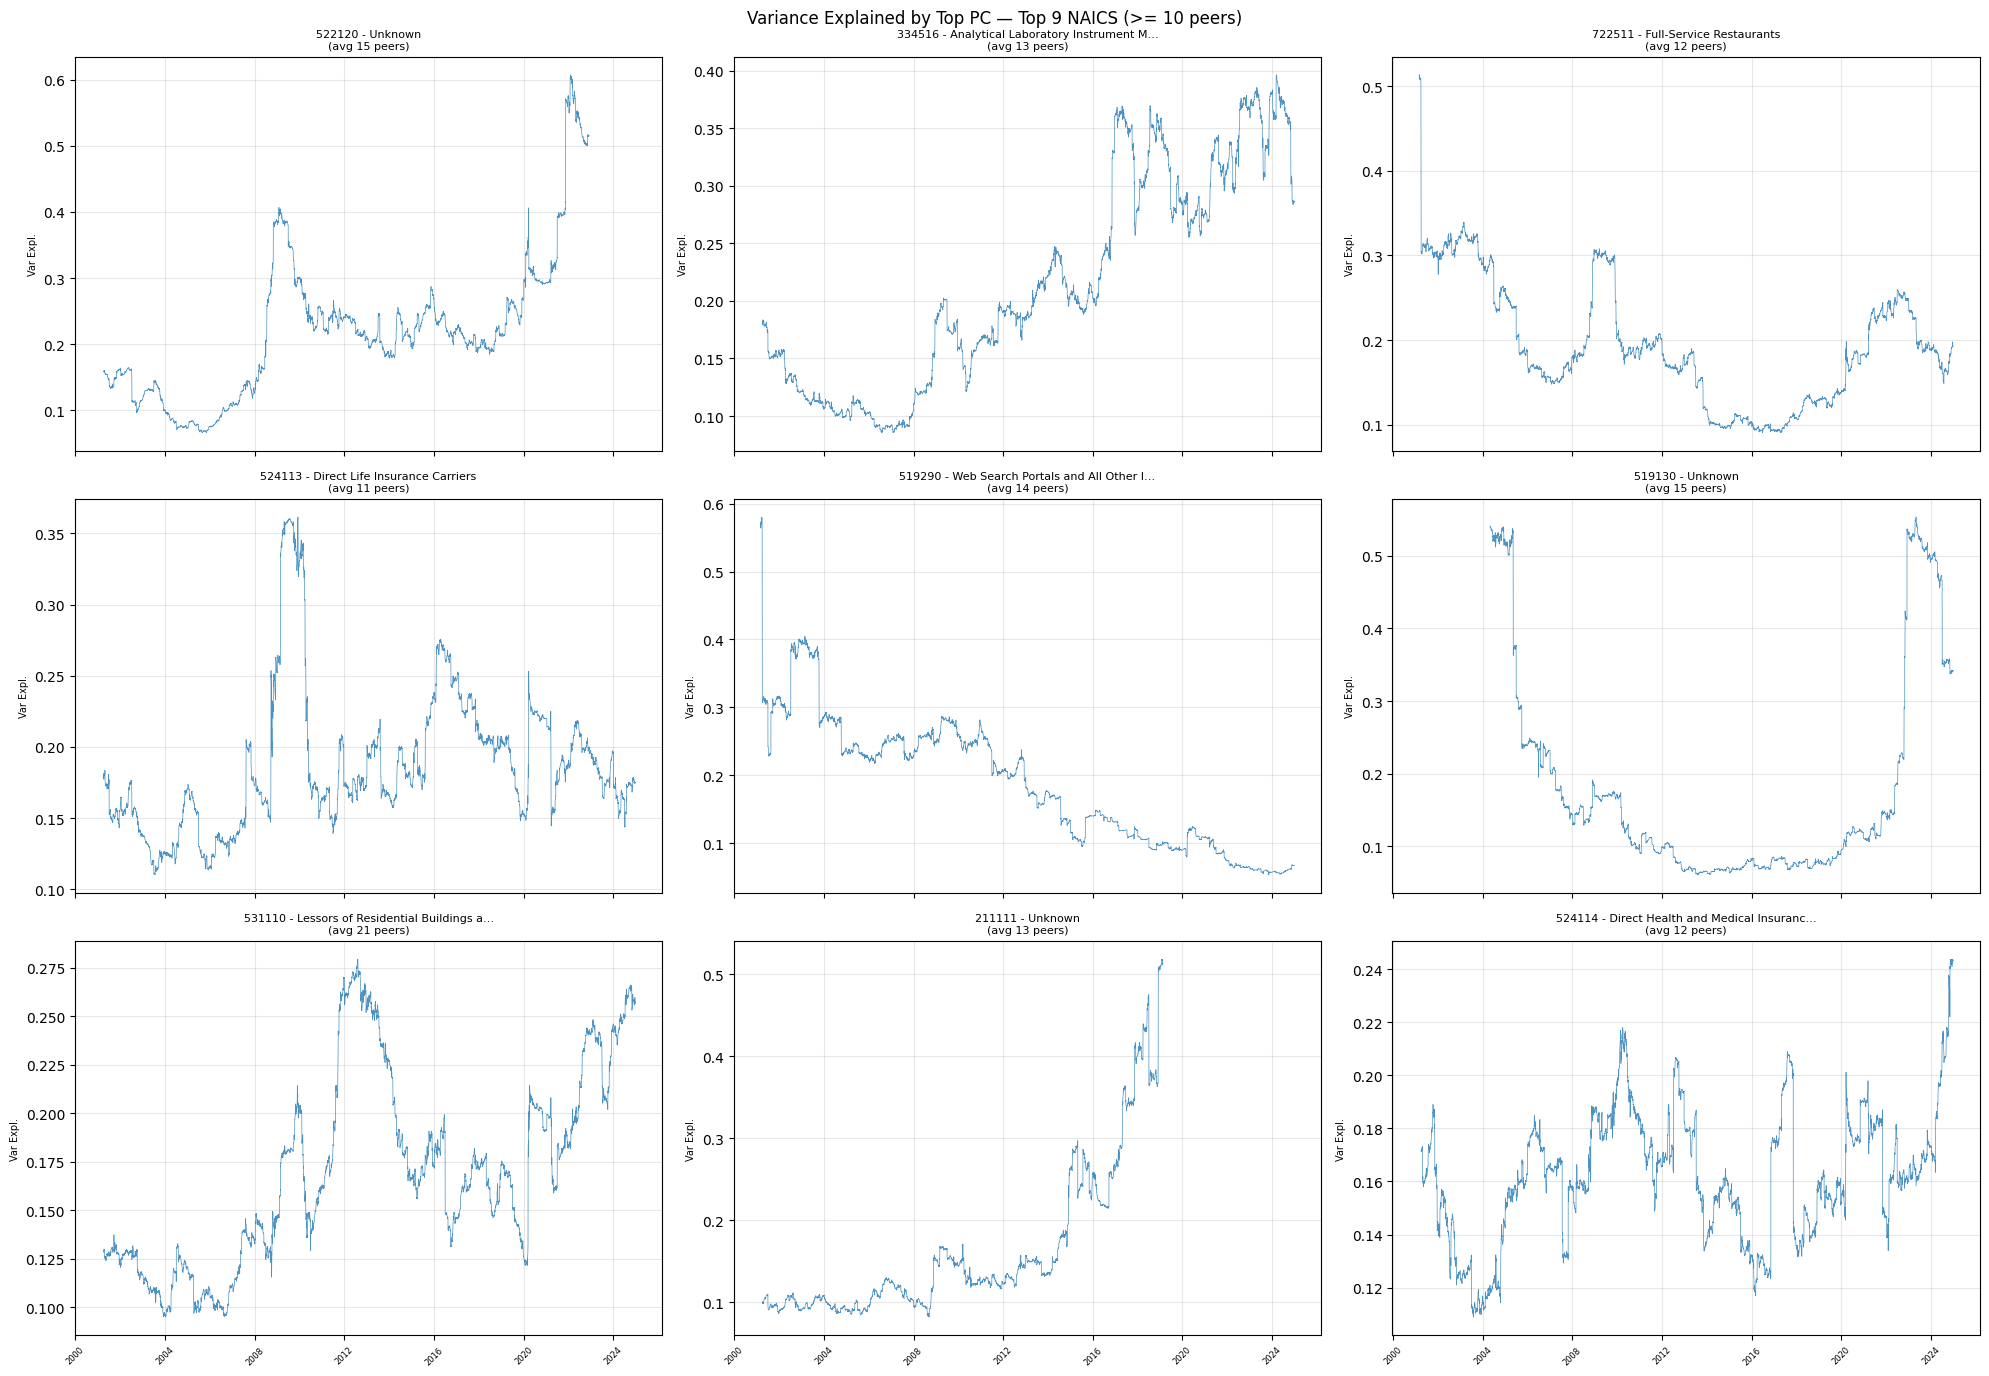

In [16]:
# ── Top 9 plot (filtered to meaningful group sizes) ───────
top9 = filtered.head(9)['naics'].to_list()
top9_names = dict(zip(
    filtered['naics'].to_list(),
    filtered['naics_name'].to_list()
))

fig, axes = plt.subplots(3, 3, figsize=(20, 14), sharex=True)
axes_flat = axes.flatten()

for idx, naics_code in enumerate(top9):
    ax = axes_flat[idx]
    sub_data = (
        all_eig_df
        .filter(pl.col('naics') == naics_code)
        .group_by('date')
        .agg([
            pl.col('var_explained').mean().alias('avg_var_explained'),
            pl.col('n_peers').mean().alias('avg_peers'),
        ])
        .sort('date')
    )
    ax.plot(sub_data['date'].to_list(), sub_data['avg_var_explained'].to_numpy(),
            linewidth=0.5, alpha=0.8)

    name = top9_names.get(naics_code, "Unknown")
    if len(name) > 35:
        name = name[:34] + "…"
    avg_peers = sub_data['avg_peers'].mean()
    ax.set_title(f'{naics_code} - {name}\n(avg {avg_peers:.0f} peers)', fontsize=8)
    ax.set_ylabel('Var Expl.', fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=6)

plt.suptitle(f'Variance Explained by Top PC — Top 9 NAICS (>= {MIN_PEERS_FOR_PLOT} peers)', fontsize=12)
plt.tight_layout()
plt.show()

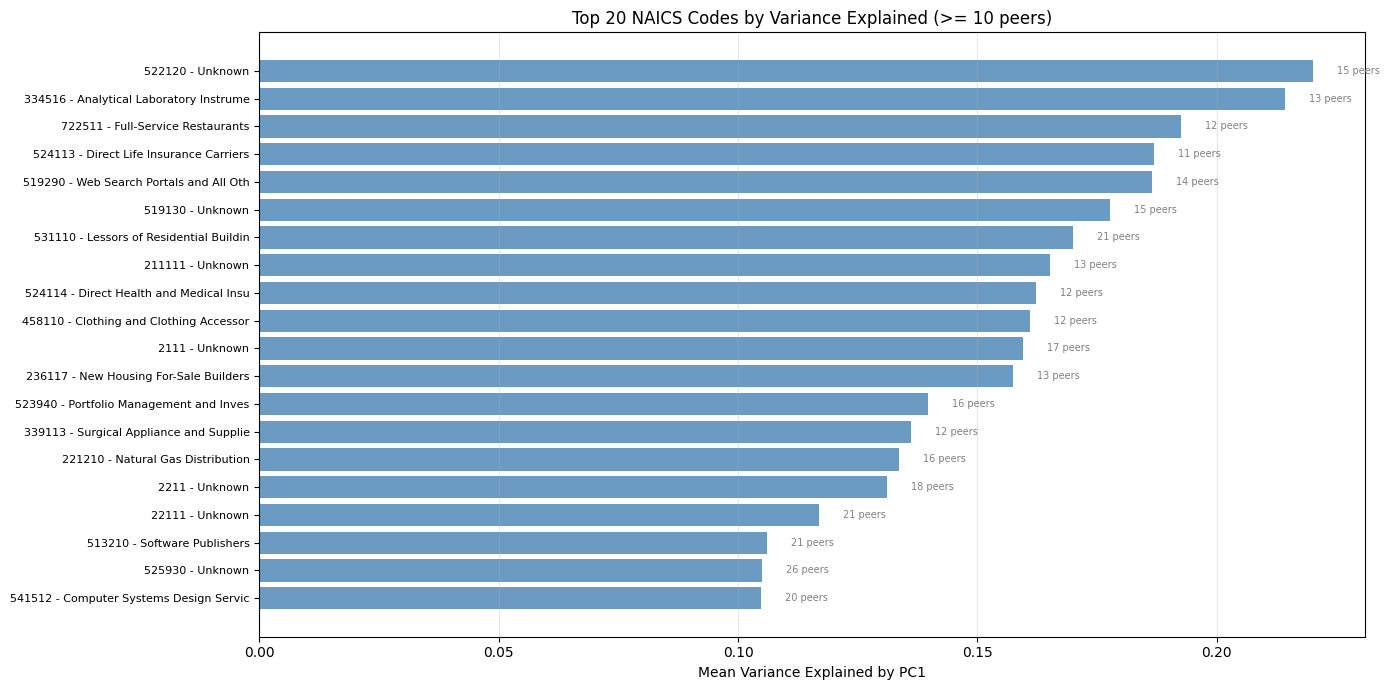

In [17]:
# ── Bar chart: top 20 NAICS by var explained (filtered) ───
top20 = filtered.head(20)

fig, ax = plt.subplots(figsize=(14, 7))
labels = [f"{r['naics']} - {r['naics_name'][:30]}" for r in top20.iter_rows(named=True)]
values = top20['mean_var_explained'].to_numpy()
peers = top20['mean_peers'].to_numpy()

bars = ax.barh(range(len(labels)), values, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel('Mean Variance Explained by PC1')
ax.set_title(f'Top 20 NAICS Codes by Variance Explained (>= {MIN_PEERS_FOR_PLOT} peers)')
ax.invert_yaxis()

# Annotate with peer count
for i, (v, p) in enumerate(zip(values, peers)):
    ax.text(v + 0.005, i, f'{p:.0f} peers', va='center', fontsize=7, color='grey')

ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

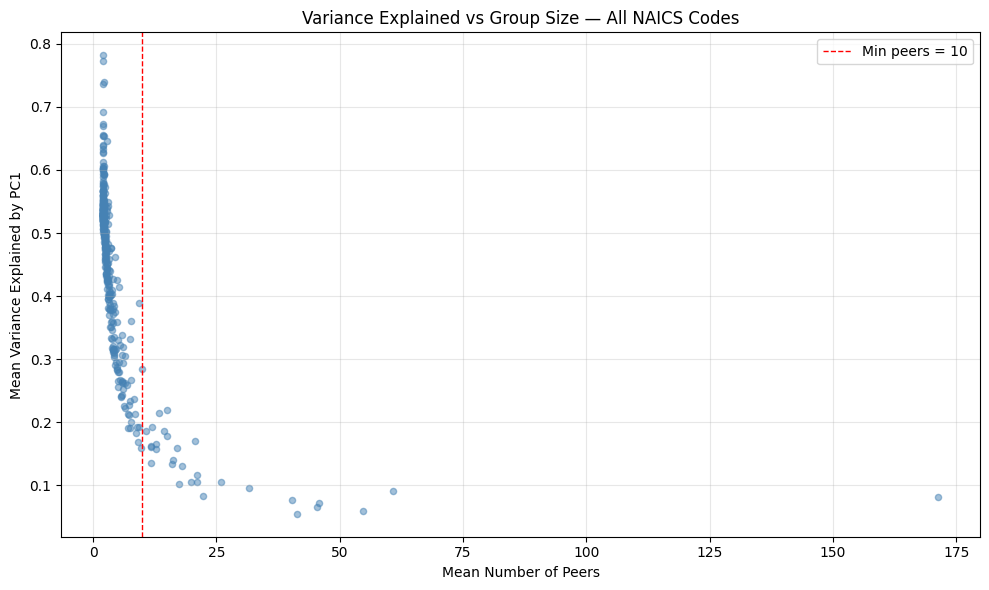

In [20]:
# ── Scatter: var explained vs number of peers ─────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(per_naics['mean_peers'].to_numpy(),
           per_naics['mean_var_explained'].to_numpy(),
           alpha=0.5, s=20, color='steelblue')
ax.axvline(MIN_PEERS_FOR_PLOT, ls='--', color='red', lw=1, label=f'Min peers = {MIN_PEERS_FOR_PLOT}')
ax.set_xlabel('Mean Number of Peers')
# ax.set_xlim(60)
ax.set_ylabel('Mean Variance Explained by PC1')
ax.set_title('Variance Explained vs Group Size — All NAICS Codes')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()